In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/brain-tumor-project"
import os
os.makedirs(PROJECT_DIR, exist_ok=True)

print("PROJECT_DIR =", PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR = /content/drive/MyDrive/brain-tumor-project


In [2]:
!ls -l /content/drive/MyDrive/brain-tumor-project/data


total 4
drwx------ 2 root root 4096 Nov 15 08:50 brain_tumor


In [3]:
!ls -l /content/drive/MyDrive/brain-tumor-project/data/brain_tumor


total 88870
-rw------- 1 root root 91002358 Nov 15 08:58 archive.zip


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/brain-tumor-project/data/brain_tumor/archive.zip"
extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted into:", extract_path)


Extracted into: /content/brain_tumor_dataset


In [5]:
dataset_path = "/content/brain_tumor_dataset/Training"

categories = [
    'glioma_tumor',
    'meningioma_tumor',
    'no_tumor',
    'pituitary_tumor'
]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import gradio as gr


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from keras import models, layers, applications
import seaborn as sns
from collections import Counter
import pandas as pd
from tensorflow import keras
from tensorflow.keras import applications
from tensorflow.keras.optimizers import Adam
import tensorflow as tf



In [7]:
def plot_history(history, title_prefix="Model"):

    plt.figure(figsize=(7,5))
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


    plt.figure(figsize=(7,5))
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f"{title_prefix} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


In [8]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

Loading: /content/brain_tumor_dataset/Training/glioma_tumor


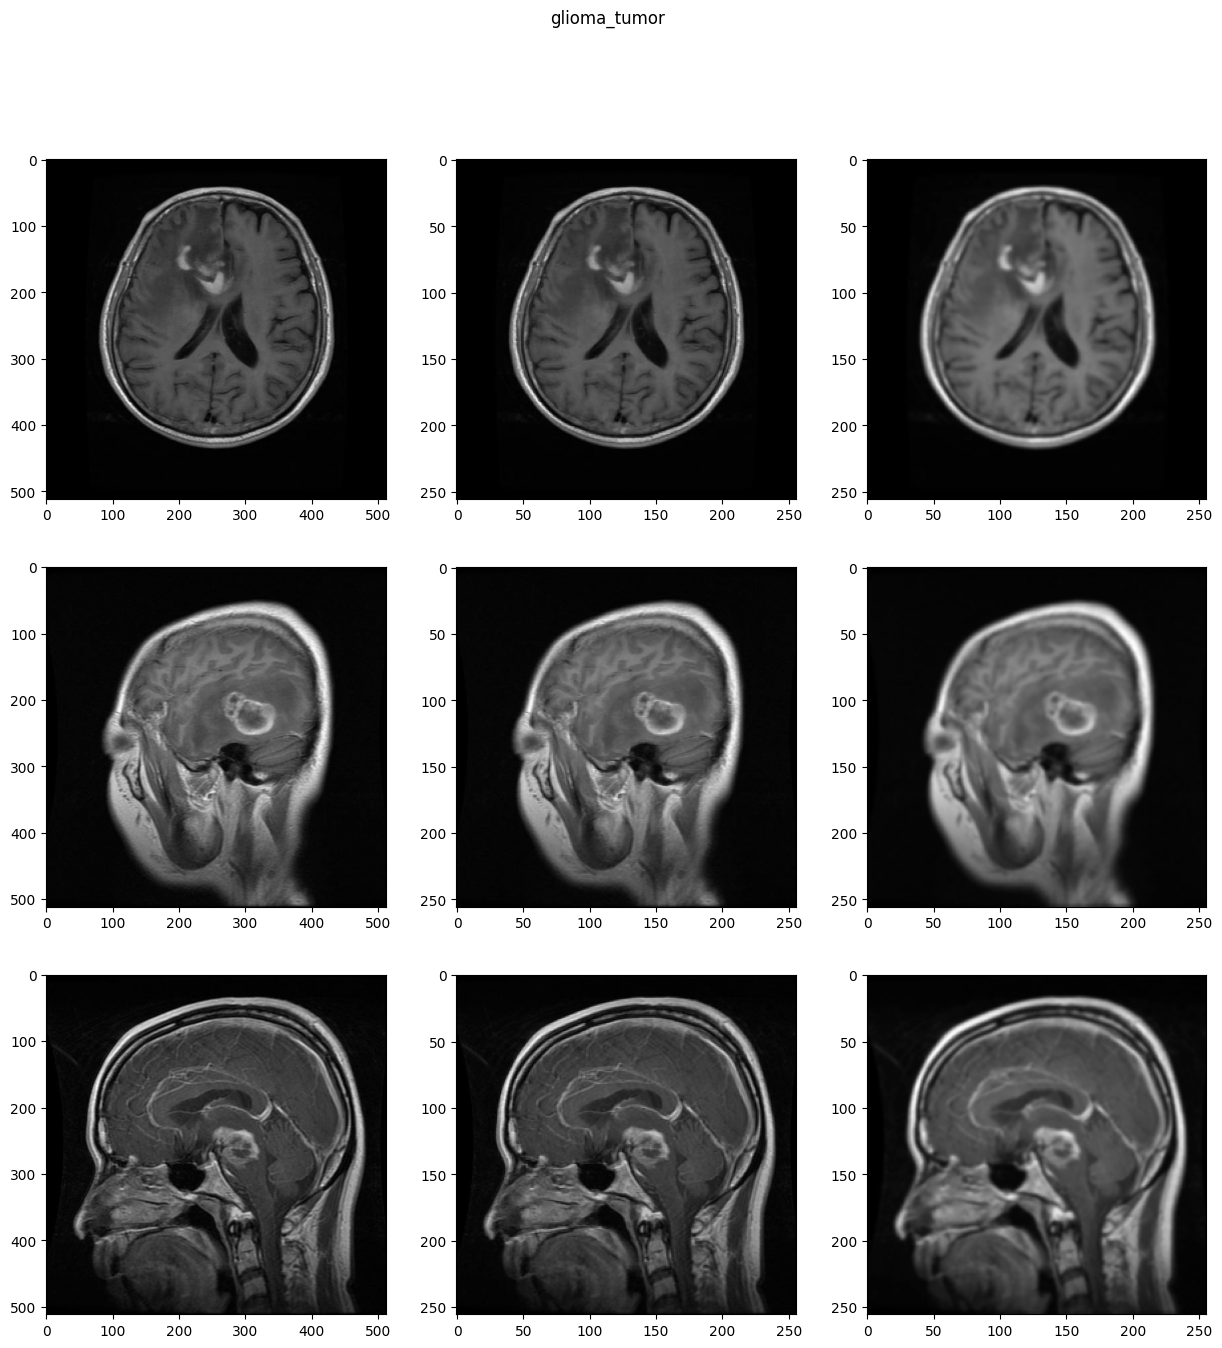

Loading: /content/brain_tumor_dataset/Training/meningioma_tumor


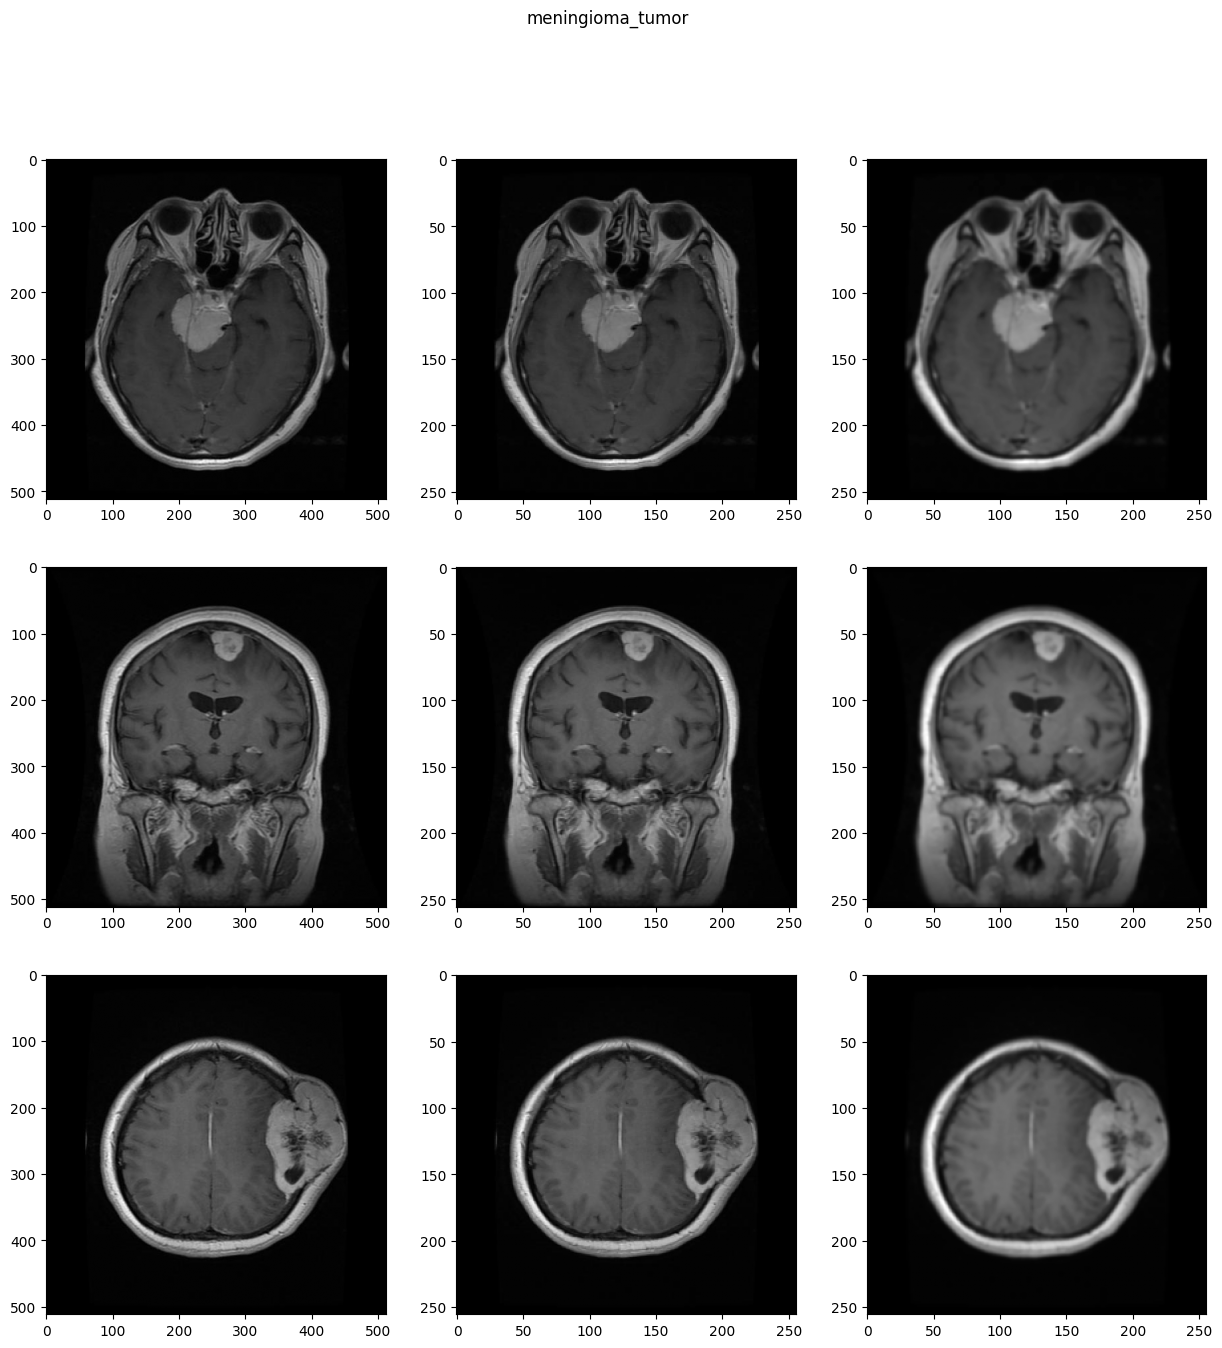

Loading: /content/brain_tumor_dataset/Training/no_tumor


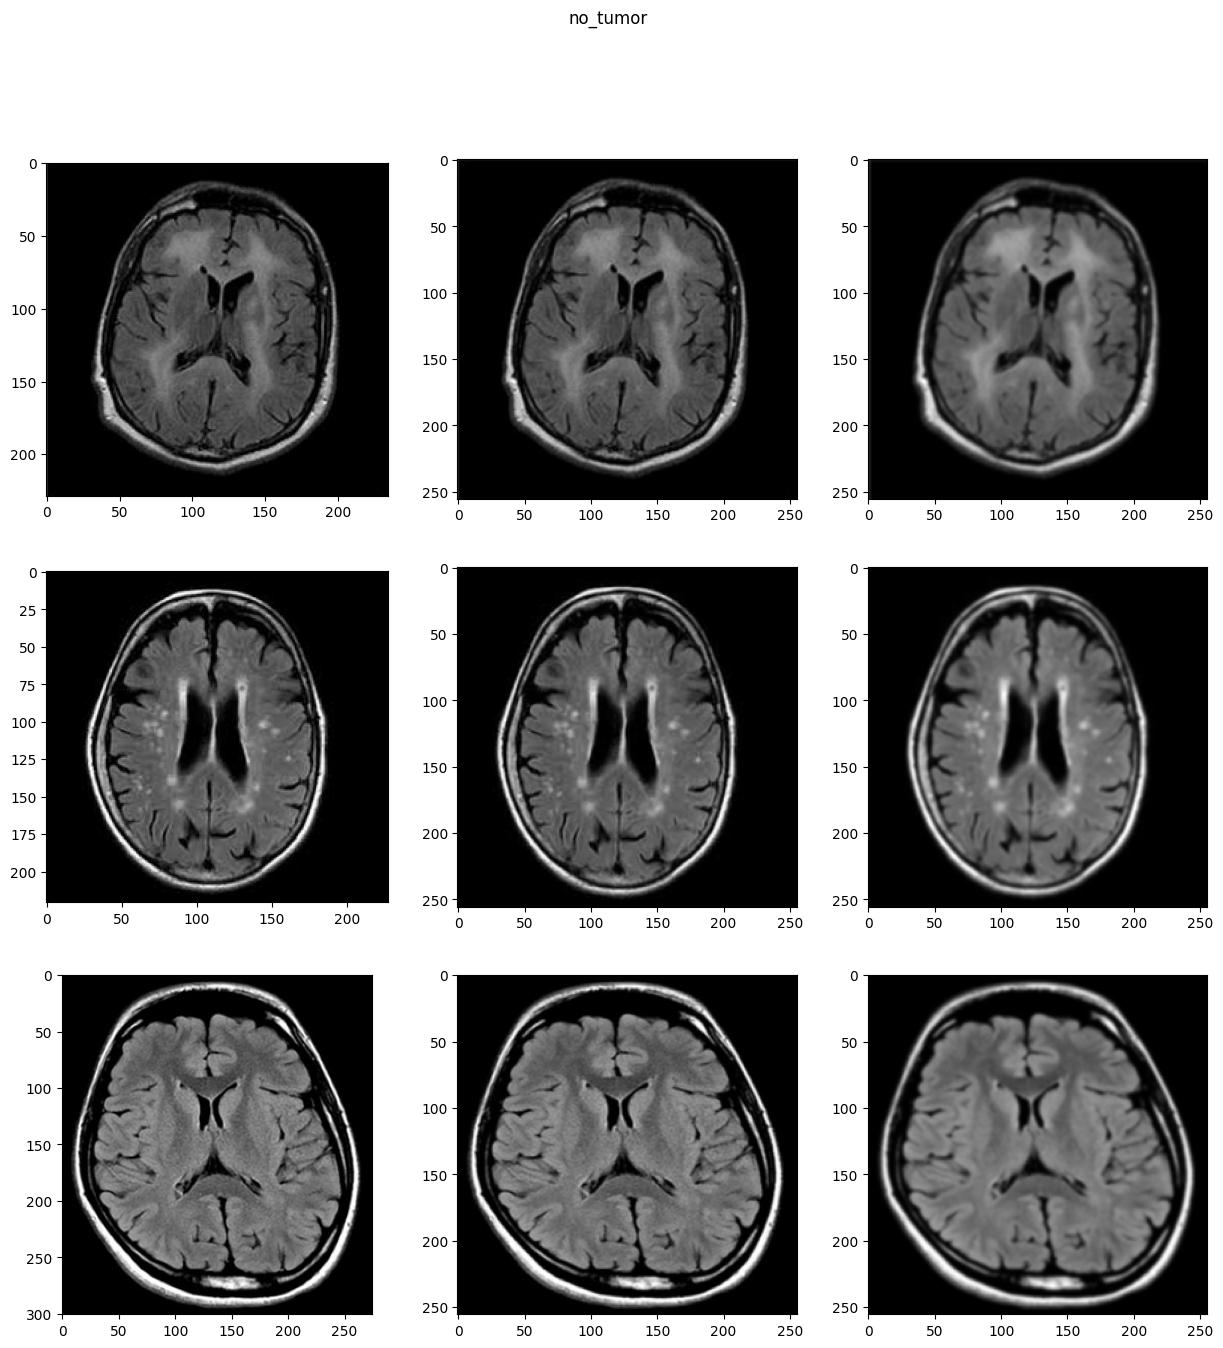

Loading: /content/brain_tumor_dataset/Training/pituitary_tumor


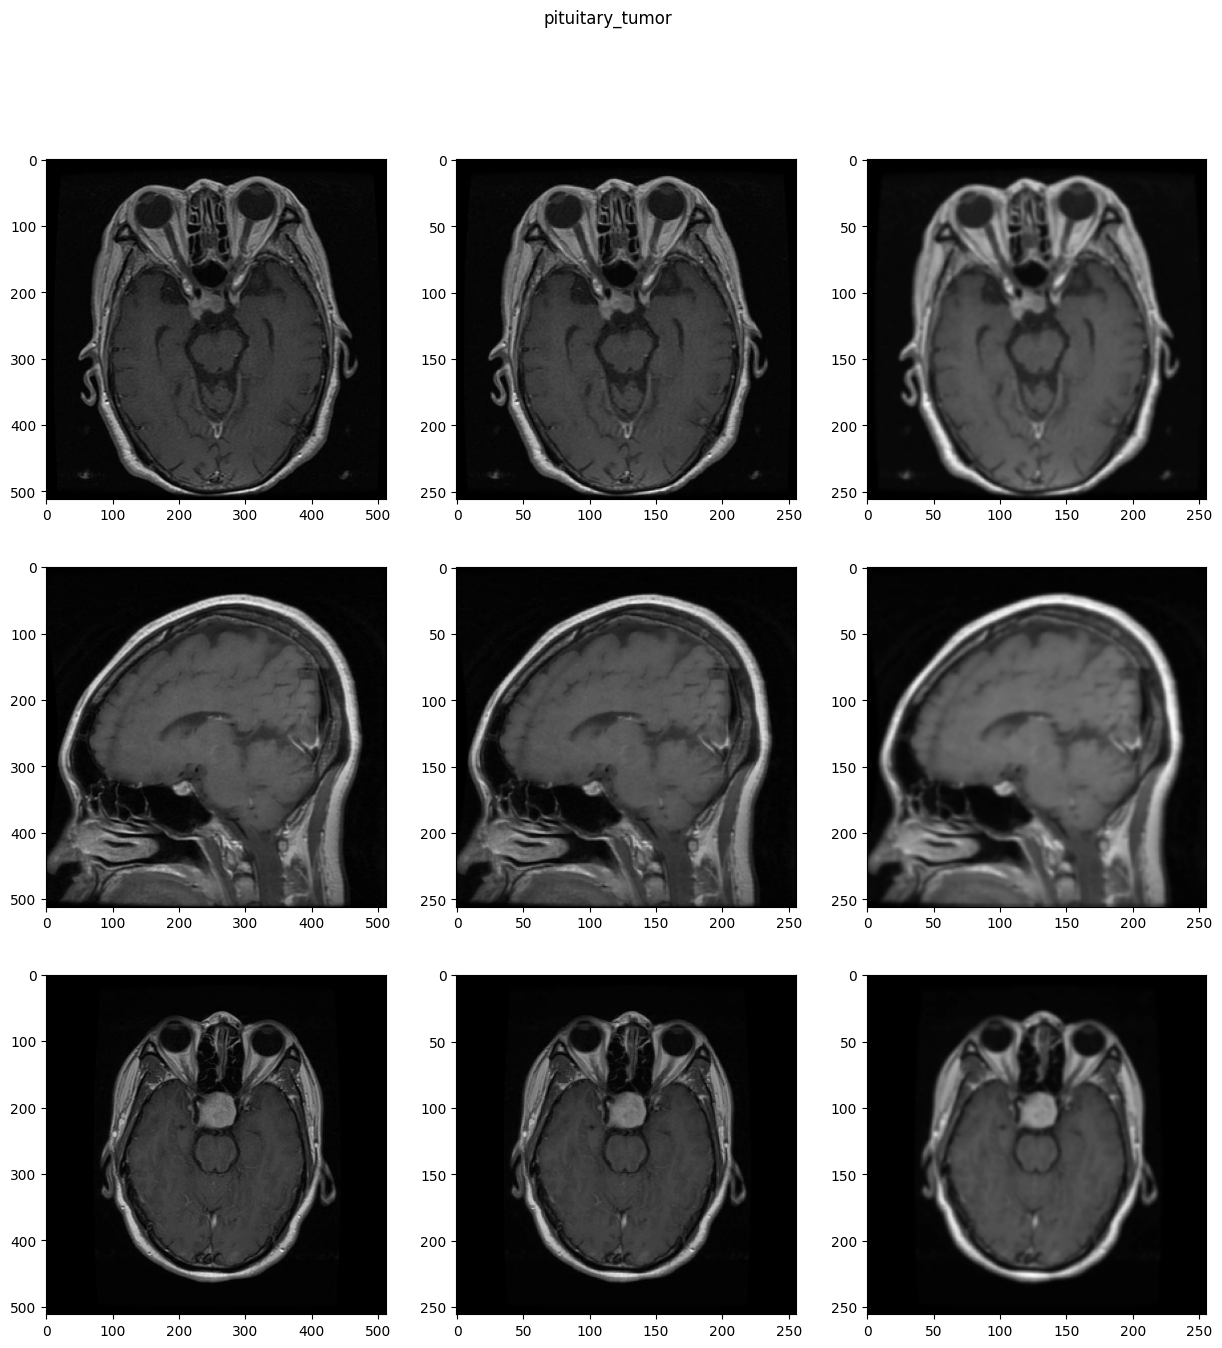

Total images loaded: 2870


In [9]:
data = []
img_size = 256

for category in categories:
    path = os.path.join(dataset_path, category)
    class_num = categories.index(category)

    print("Loading:", path)

    cnt = 0
    samples = 3

    fig, ax = plt.subplots(samples, 3, figsize=(15,15))
    fig.suptitle(category)

    for file in os.listdir(path):
        filepath = os.path.join(path, file)

        img = cv2.imread(filepath, 0)  # grayscale
        img_resized = cv2.resize(img, (img_size, img_size))
        img_blurred = cv2.GaussianBlur(img_resized, (5,5), 0)

        data.append([img_blurred, class_num])

        if cnt < samples:
            ax[cnt,0].imshow(img, cmap='gray')
            ax[cnt,1].imshow(img_resized, cmap='gray')
            ax[cnt,2].imshow(img_blurred, cmap='gray')
            cnt += 1

    plt.show()

print("Total images loaded:", len(data))


In [10]:

def denoise_image(img):
    img = img.squeeze()
    img_uint8 = (img * 255).astype(np.uint8)

    gaussian = cv2.GaussianBlur(img_uint8, (5,5), 0)
    median   = cv2.medianBlur(img_uint8, 5)
    bilateral = cv2.bilateralFilter(img_uint8, 9, 75, 75)

    return gaussian/255.0, median/255.0, bilateral/255.0

def apply_clahe(img):
    img = img.squeeze()
    img_uint8 = (img * 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(img_uint8)

    return enhanced/255.0


In [11]:
X, y = [], []

for feature, label in data:
    X.append(feature)
    y.append(label)

X = np.array(X).reshape(-1, img_size, img_size, 1)
y = np.array(y)

y_binary = np.array([0 if label == categories.index("no_tumor") else 1 for label in y])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2870, 256, 256, 1)
y shape: (2870,)


In [12]:
Xtrain, XVld, ytrain, yVld = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)


In [14]:
Xtrain_flat = Xtrain.reshape(Xtrain.shape[0], img_size * img_size)

sm = SMOTE()
Xtrain_flat, ytrain = sm.fit_resample(Xtrain_flat, ytrain)

Xtrain = Xtrain_flat.reshape(-1, img_size, img_size, 1)

new_weights = {
    i: Xtrain.shape[0] / (4 * Counter(ytrain)[i])
    for i in range(4)
}



In [15]:
y_binary_train = np.array([
    0 if c == categories.index("no_tumor") else 1
    for c in ytrain
])

y_binary_val = np.array([
    0 if c == categories.index("no_tumor") else 1
    for c in yVld
])


In [16]:
def createModel(architecture='custom'):

    if architecture == 'VGG16':
        base = applications.VGG16(
            weights='imagenet',
            include_top=False,
            input_shape=(256,256,3)
        )
        base.trainable = False

        model = models.Sequential([
            base,
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(4, activation='softmax')
        ])

    elif architecture == 'ResNet50':
        base = applications.ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(256,256,3)
        )
        base.trainable = False

        model = models.Sequential([
            base,
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(4, activation='softmax')
        ])

    else:
        model = models.Sequential([
            data_augmentation,
            layers.Conv2D(96, (11,11), strides=(4,4), input_shape=(256,256,1)),
            layers.MaxPooling2D((2,2)),

            layers.Conv2D(64, (3,3), activation='relu'),
            layers.MaxPooling2D((2,2)),

            layers.Conv2D(64, (3,3), activation='relu'),
            layers.MaxPooling2D((2,2)),

            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(256, activation='relu'),
            layers.Dense(4, activation='softmax')
        ])

    return model


In [17]:
def build_efficientnet():
    base = applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(256,256,3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    return model


def build_densenet121():
    base = applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(256,256,3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    return model


In [18]:
def build_mobilenetv2():
    base = applications.MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(256,256,3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(4, activation='softmax')
    ])
    return model


In [19]:
def build_inceptionv3():
    base = applications.InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(256,256,3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(4, activation='softmax')
    ])
    return model


In [20]:
def build_xception():
    base = applications.Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(256,256,3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(4, activation='softmax')
    ])
    return model


In [21]:
def build_shufflenet():
    base = applications.MobileNet(
        weights='imagenet',
        include_top=False,
        input_shape=(256,256,3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(4, activation='softmax')
    ])
    return model


In [22]:
def build_alexnet():
    model = models.Sequential([
        layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(256,256,3)),
        layers.MaxPool2D(3, strides=2),

        layers.Conv2D(256, (5,5), padding='same', activation='relu'),
        layers.MaxPool2D(3, strides=2),

        layers.Conv2D(384, (3,3), padding='same', activation='relu'),
        layers.Conv2D(384, (3,3), padding='same', activation='relu'),
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.MaxPool2D(3, strides=2),

        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    return model


In [23]:
def build_mscnn():
    inp = layers.Input(shape=(256,256,3))

    b1 = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    b2 = layers.Conv2D(32, (5,5), padding='same', activation='relu')(inp)
    b3 = layers.Conv2D(32, (7,7), padding='same', activation='relu')(inp)

    merged = layers.concatenate([b1, b2, b3])
    x = layers.MaxPool2D()(merged)
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inp, out)
    return model


In [24]:
def build_vit_small():
    inputs = layers.Input(shape=(256,256,3))

    patch_size = 16
    num_patches = (256 // patch_size) ** 2
    projection_dim = 64


    patches = layers.Conv2D(
        filters=projection_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding="valid"
    )(inputs)
    patches = layers.Reshape((num_patches, projection_dim))(patches)


    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embeddings = layers.Embedding(
        input_dim=num_patches,
        output_dim=projection_dim
    )(positions)
    x = patches + pos_embeddings


    for _ in range(4):

        x1 = layers.LayerNormalization(epsilon=1e-6)(x)

        attention_output = layers.MultiHeadAttention(
            num_heads=4, key_dim=projection_dim)(x1, x1)
        x2 = layers.Add()([attention_output, x])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        mlp_output = layers.Dense(128, activation='relu')(x3)
        mlp_output = layers.Dense(projection_dim)(mlp_output)
        x = layers.Add()([mlp_output, x2])


    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(4, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model


In [25]:
from sklearn.model_selection import train_test_split

X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)


In [26]:
X_train_bin_vgg = np.repeat(X_train_bin, 3, axis=-1)
X_val_bin_vgg   = np.repeat(X_val_bin,   3, axis=-1)


In [27]:
from tensorflow.keras import applications, models, layers

def build_binary_vgg16():
    base = applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(256,256,3)
    )
    base.trainable = False

    x = layers.Flatten()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=base.input, outputs=output)
    return model


In [28]:
binary_vgg = build_binary_vgg16()

binary_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = binary_vgg.fit(
    X_train_bin_vgg, y_train_bin,
    validation_data=(X_val_bin_vgg, y_val_bin),
    batch_size=16,
    epochs=5
)


Epoch 1/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 55s 283ms/step - accuracy: 0.8338 - loss: 1.7624 - val_accuracy: 0.9564 - val_loss: 0.4338
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.9319 - loss: 0.5084 - val_accuracy: 0.9652 - val_loss: 0.4637
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.9578 - loss: 0.2258 - val_accuracy: 0.9652 - val_loss: 0.3660
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.9542 - loss: 0.2880 - val_accuracy: 0.9617 - val_loss: 0.3814
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.9691 - loss: 0.1453 - val_accuracy: 0.9739 - val_loss: 0.3046


In [29]:
from sklearn.metrics import classification_report

preds = (binary_vgg.predict(X_val_bin_vgg) > 0.5).astype(int).flatten()

print("\n=== BINARY VGG16 CLASSIFICATION REPORT ===\n")
print(classification_report(y_val_bin, preds, target_names=["No Tumor", "Tumor"]))


18/18 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step

=== BINARY VGG16 CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    No Tumor       0.88      0.94      0.91        79
       Tumor       0.99      0.98      0.98       495

    accuracy                           0.97       574
   macro avg       0.94      0.96      0.95       574
weighted avg       0.97      0.97      0.97       574



In [30]:
Xtrain_vgg = np.repeat(Xtrain, 3, axis=-1)
XVld_vgg   = np.repeat(XVld,   3, axis=-1)

print("Xtrain_vgg:", Xtrain_vgg.shape)
print("XVld_vgg:", XVld_vgg.shape)

Xtrain_vgg: (2684, 256, 256, 3)
XVld_vgg: (574, 256, 256, 3)


In [31]:
from keras import models, layers, applications

def build_vgg16_imagenet():
    base = applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(256, 256, 3)
    )


    for layer in base.layers:
        layer.trainable = False

    model = models.Sequential([
        base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    return model

vgg16_tl = build_vgg16_imagenet()
vgg16_tl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,136,964 (88.26 MB)

 Trainable params: 8,422,276 (32.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [32]:
from keras.optimizers import Adam

vgg16_tl.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [33]:
history_vgg_tl = vgg16_tl.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step - accuracy: 0.4531 - loss: 5.2708 - val_accuracy: 0.7091 - val_loss: 0.7924
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step - accuracy: 0.5814 - loss: 1.3641 - val_accuracy: 0.7840 - val_loss: 0.6341
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.6429 - loss: 1.0771 - val_accuracy: 0.8153 - val_loss: 0.5467


In [34]:
y_pred_vgg_tl = vgg16_tl.predict(XVld_vgg)
y_pred_vgg_tl = np.argmax(y_pred_vgg_tl, axis=1)


18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step


In [35]:
from sklearn.metrics import classification_report

print(classification_report(yVld, y_pred_vgg_tl, target_names=categories))


                  precision    recall  f1-score   support

    glioma_tumor       0.83      0.88      0.85       179
meningioma_tumor       0.80      0.61      0.69       169
        no_tumor       0.85      0.83      0.84        70
 pituitary_tumor       0.80      0.96      0.87       156

        accuracy                           0.82       574
       macro avg       0.82      0.82      0.81       574
    weighted avg       0.81      0.82      0.81       574



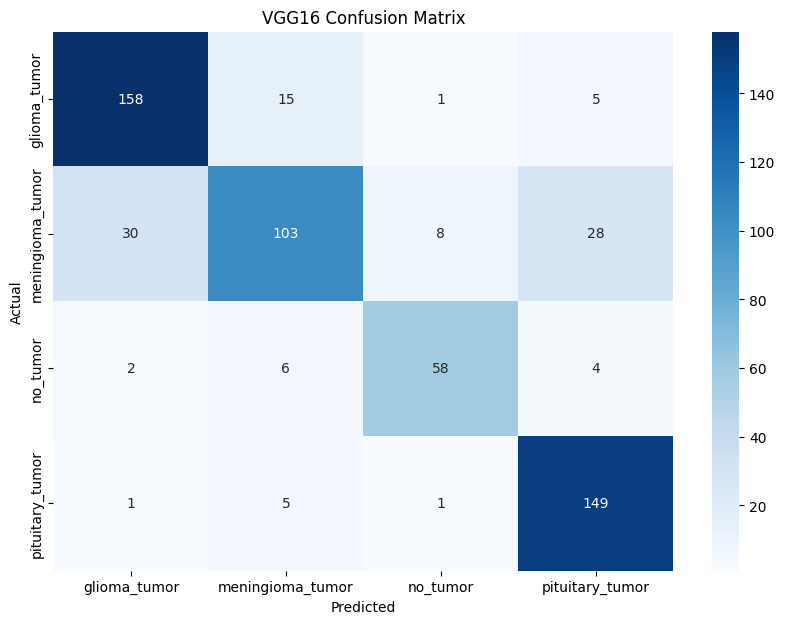

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_vgg = confusion_matrix(yVld, y_pred_vgg_tl)

plt.figure(figsize=(10,7))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


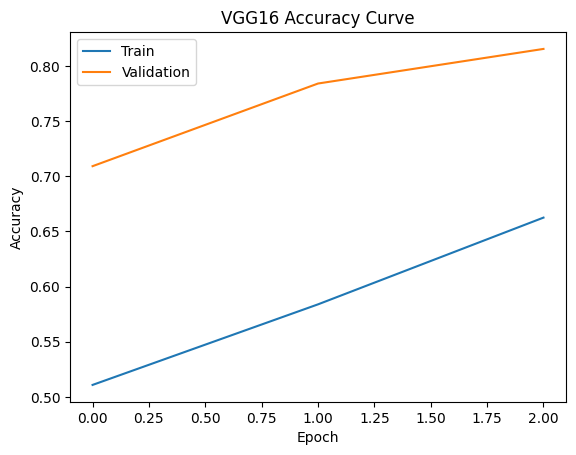

In [37]:
plt.plot(history_vgg_tl.history['accuracy'], label='Train')
plt.plot(history_vgg_tl.history['val_accuracy'], label='Validation')
plt.title("VGG16 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


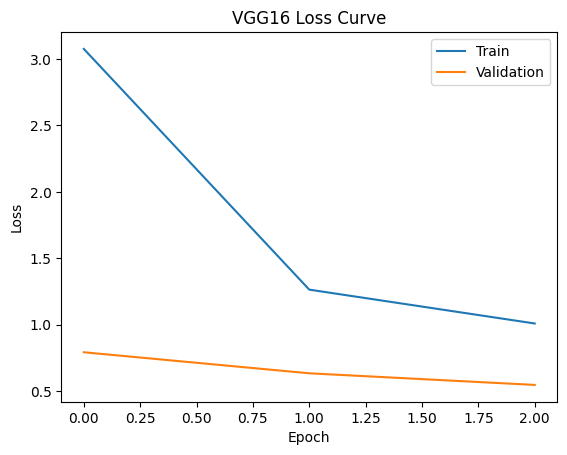

In [38]:
plt.plot(history_vgg_tl.history['loss'], label='Train')
plt.plot(history_vgg_tl.history['val_loss'], label='Validation')
plt.title("VGG16 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [39]:
Xtrain_resnet = Xtrain_vgg
XVld_resnet   = XVld_vgg


In [40]:
from keras import models, layers, applications

def build_resnet50():
    base = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(256, 256, 3)
    )


    for layer in base.layers:
        layer.trainable = False

    model = models.Sequential([
        base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')  # 4 classes
    ])

    return model

resnet50_tl = build_resnet50()
resnet50_tl.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,175,812 (218.11 MB)

 Trainable params: 33,588,100 (128.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [41]:
from keras.optimizers import Adam

resnet50_tl.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [42]:
history_resnet = resnet50_tl.fit(
    Xtrain_resnet, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_resnet, yVld),
    class_weight=new_weights
)


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.4675 - loss: 3.3339 - val_accuracy: 0.7509 - val_loss: 0.6898
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.6152 - loss: 1.0254 - val_accuracy: 0.7944 - val_loss: 0.6160
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.6697 - loss: 0.9041 - val_accuracy: 0.8415 - val_loss: 0.6014


In [43]:
y_pred_resnet = resnet50_tl.predict(XVld_resnet)
y_pred_resnet = np.argmax(y_pred_resnet, axis=1)


18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 489ms/step


In [44]:
from sklearn.metrics import classification_report

print(classification_report(yVld, y_pred_resnet, target_names=categories))


                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.78      0.87       179
meningioma_tumor       0.70      0.85      0.77       169
        no_tumor       0.91      0.83      0.87        70
 pituitary_tumor       0.87      0.91      0.89       156

        accuracy                           0.84       574
       macro avg       0.86      0.84      0.85       574
    weighted avg       0.86      0.84      0.84       574



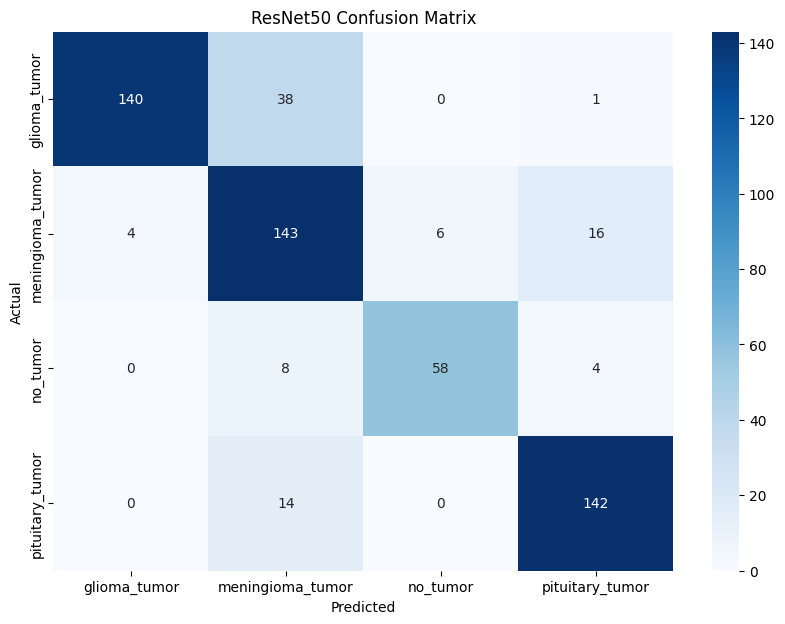

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_resnet = confusion_matrix(yVld, y_pred_resnet)

plt.figure(figsize=(10,7))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


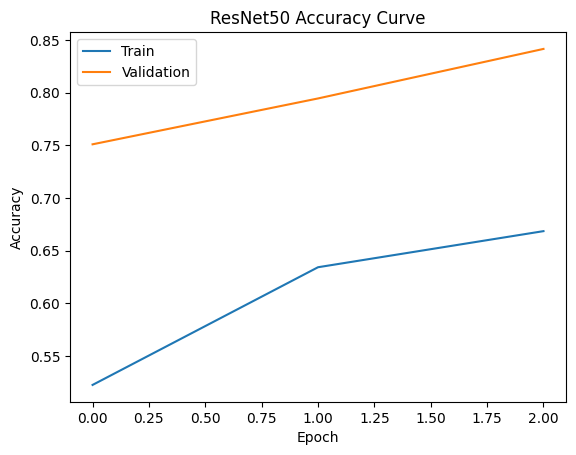

In [46]:
plt.plot(history_resnet.history['accuracy'], label='Train')
plt.plot(history_resnet.history['val_accuracy'], label='Validation')
plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

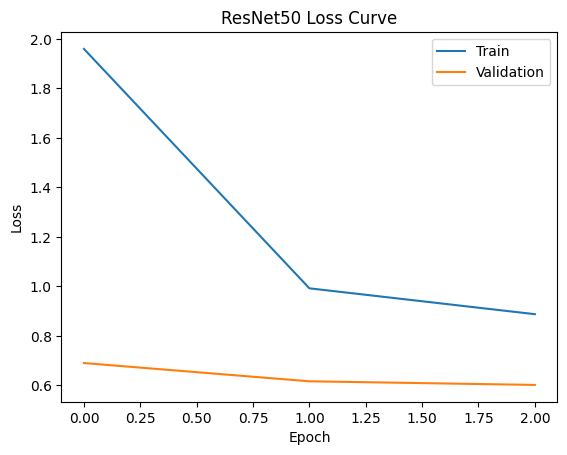

In [47]:
plt.plot(history_resnet.history['loss'], label='Train')
plt.plot(history_resnet.history['val_loss'], label='Validation')
plt.title("ResNet50 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 68s 121ms/step - accuracy: 0.4907 - loss: 1.9773 - val_accuracy: 0.7613 - val_loss: 0.6017
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6571 - loss: 0.8459 - val_accuracy: 0.8275 - val_loss: 0.4419
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7330 - loss: 0.7381 - val_accuracy: 0.7979 - val_loss: 0.4932
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 852ms/step

EFFNET CLASSIFICATION REPORT

                  precision    recall  f1-score   support

    glioma_tumor       0.77      0.86      0.81       179
meningioma_tumor       0.74      0.56      0.64       169
        no_tumor       0.78      0.90      0.83        70
 pituitary_tumor       0.88      0.94      0.91       156

        accuracy                           0.80       574
       macro avg       0.79      0.81      0.80       574
    weighted avg       0.79      0.80      0.79       574



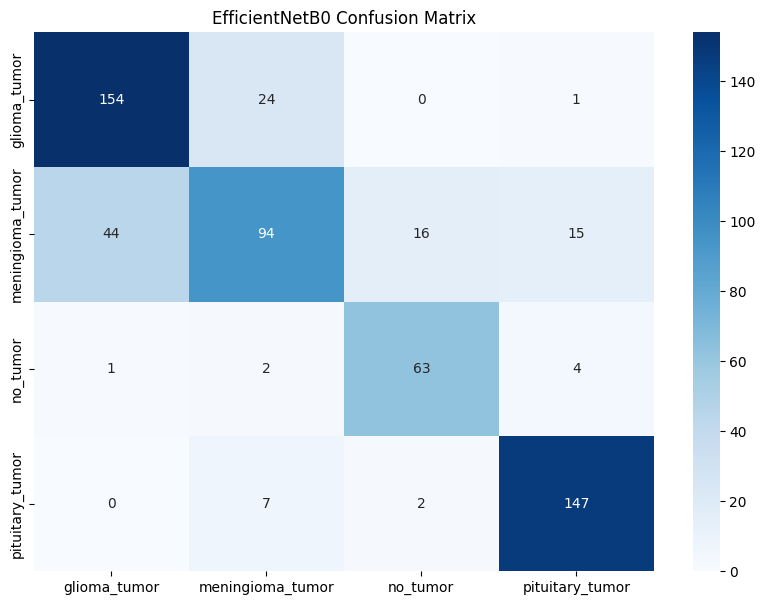

In [48]:

effnet = build_efficientnet()
effnet.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_effnet = effnet.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)

y_pred_eff = effnet.predict(XVld_vgg)
y_pred_eff = np.argmax(y_pred_eff, axis=1)

print("\nEFFNET CLASSIFICATION REPORT\n")
print(classification_report(yVld, y_pred_eff, target_names=categories))

cm_eff = confusion_matrix(yVld, y_pred_eff)
plt.figure(figsize=(10,7))
sns.heatmap(cm_eff, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories, yticklabels=categories)
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 72s 139ms/step - accuracy: 0.3444 - loss: 6.6572 - val_accuracy: 0.4669 - val_loss: 1.2518
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.3486 - loss: 1.3802 - val_accuracy: 0.5087 - val_loss: 1.2117
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.3658 - loss: 1.3242 - val_accuracy: 0.5505 - val_loss: 1.1254
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 990ms/step

DENSENET CLASSIFICATION REPORT

                  precision    recall  f1-score   support

    glioma_tumor       0.43      0.97      0.59       179
meningioma_tumor       0.00      0.00      0.00       169
        no_tumor       1.00      0.04      0.08        70
 pituitary_tumor       0.85      0.89      0.87       156

        accuracy                           0.55       574
       macro avg       0.57      0.48      0.39       574
    weighted avg       0.49      0.55      0.43       574



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


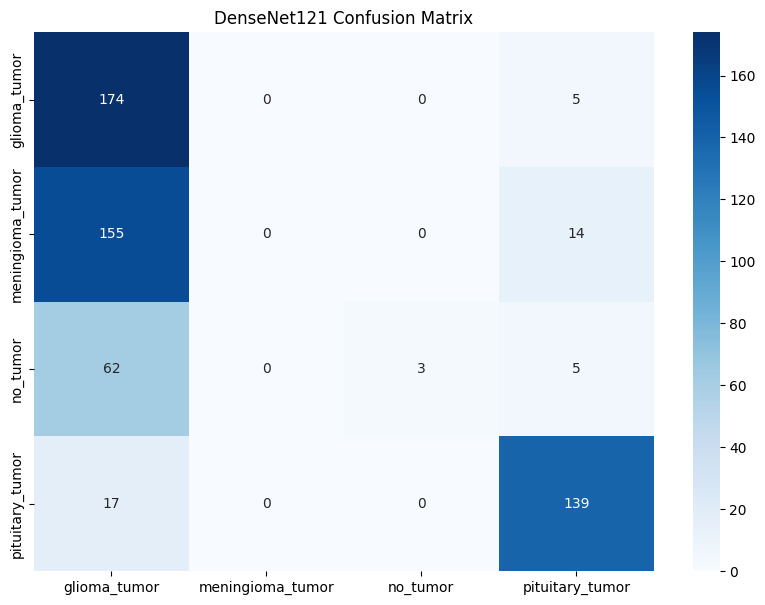

In [49]:

densenet = build_densenet121()
densenet.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dense = densenet.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)

y_pred_dense = densenet.predict(XVld_vgg)
y_pred_dense = np.argmax(y_pred_dense, axis=1)

print("\nDENSENET CLASSIFICATION REPORT\n")
print(classification_report(yVld, y_pred_dense, target_names=categories))

cm_dense = confusion_matrix(yVld, y_pred_dense)
plt.figure(figsize=(10,7))
sns.heatmap(cm_dense, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories, yticklabels=categories)
plt.title("DenseNet121 Confusion Matrix")
plt.show()


/tmp/ipython-input-1499935925.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = applications.MobileNetV2(


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 46s 91ms/step - accuracy: 0.5219 - loss: 1.0962 - val_accuracy: 0.7596 - val_loss: 0.6281
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7266 - loss: 0.6738 - val_accuracy: 0.8066 - val_loss: 0.5393
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7753 - loss: 0.5654 - val_accuracy: 0.8293 - val_loss: 0.4921


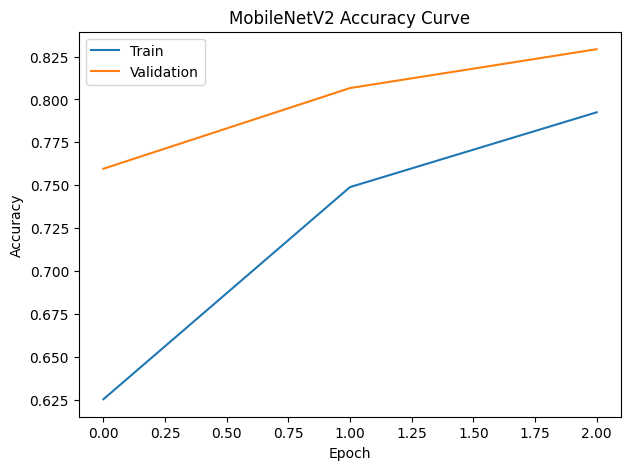

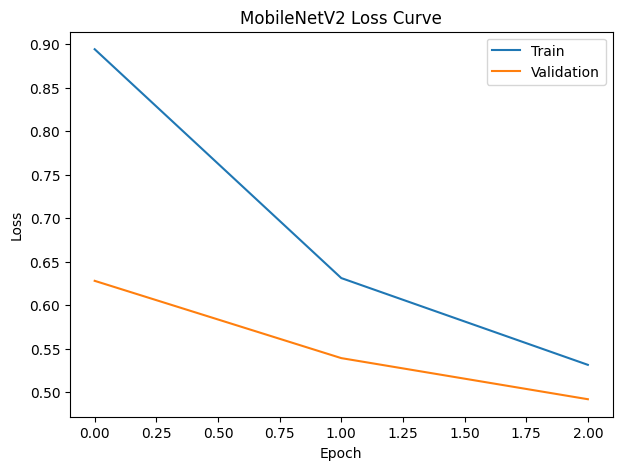

In [50]:
mobilenet = build_mobilenetv2()
mobilenet.compile(optimizer=Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_mbn = mobilenet.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)
plot_history(history_mbn, "MobileNetV2")


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - accuracy: 0.4005 - loss: 8.8404 - val_accuracy: 0.5732 - val_loss: 1.1220
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.5496 - loss: 1.3123 - val_accuracy: 0.6324 - val_loss: 0.8775
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6157 - loss: 0.9899 - val_accuracy: 0.6777 - val_loss: 0.7958


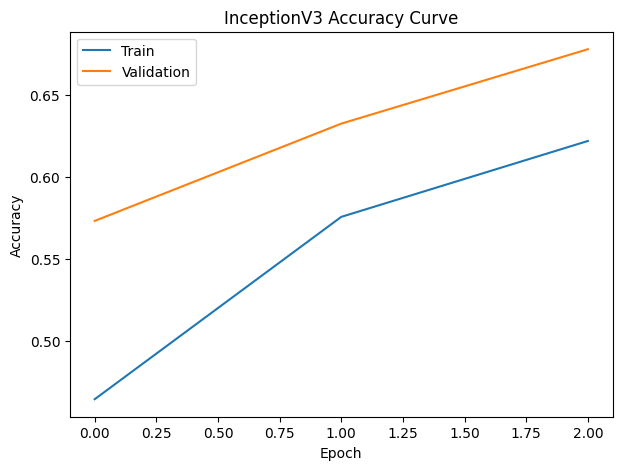

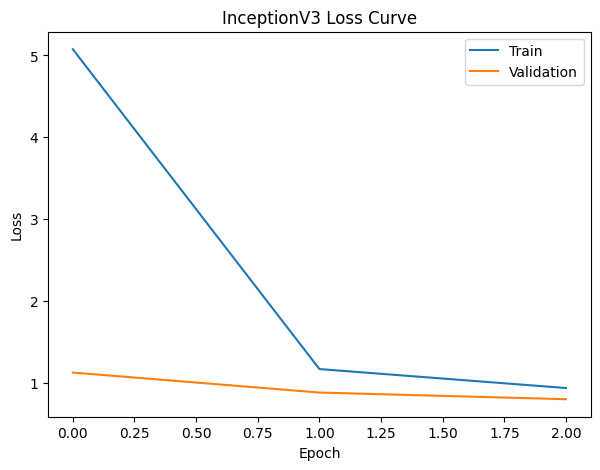

In [51]:
inception = build_inceptionv3()
inception.compile(optimizer=Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_inc = inception.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)
plot_history(history_inc, "InceptionV3")


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 88s 190ms/step - accuracy: 0.3854 - loss: 3.1731 - val_accuracy: 0.6812 - val_loss: 0.7783
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6315 - loss: 1.1493 - val_accuracy: 0.7439 - val_loss: 0.6861
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.6905 - loss: 0.8145 - val_accuracy: 0.7526 - val_loss: 0.6423


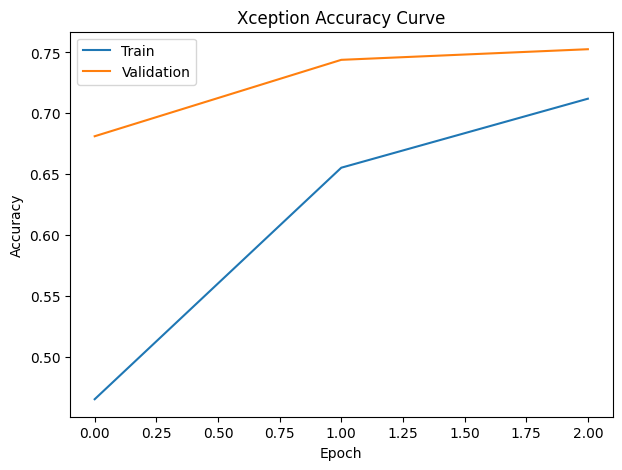

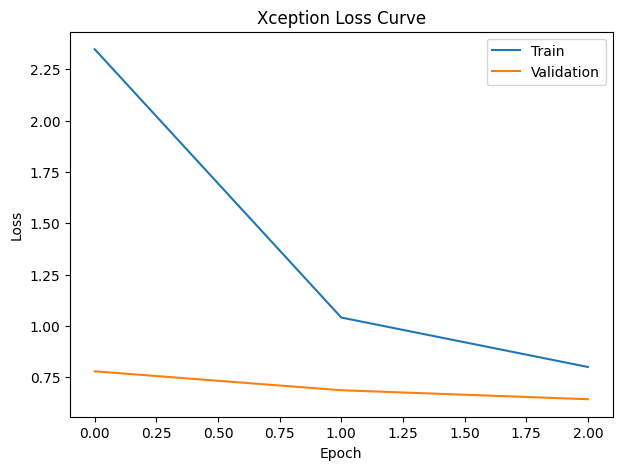

In [52]:
xception = build_xception()
xception.compile(optimizer=Adam(1e-4),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_xc = xception.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)
plot_history(history_xc, "Xception")


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.5541 - loss: 29.4592 - val_accuracy: 0.8153 - val_loss: 0.5168
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.8527 - loss: 0.4616 - val_accuracy: 0.8380 - val_loss: 0.4339
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9297 - loss: 0.2275 - val_accuracy: 0.8728 - val_loss: 0.3662


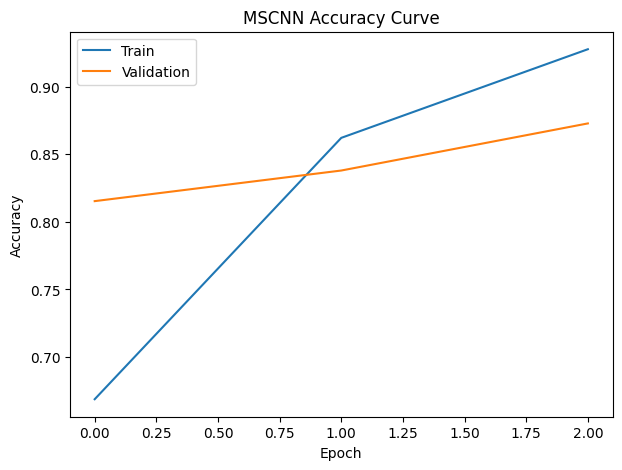

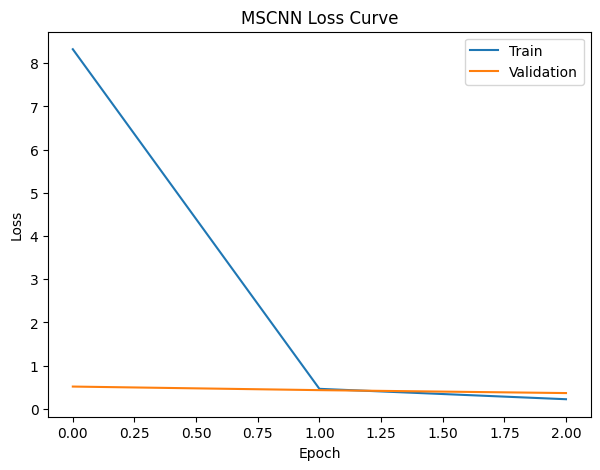

In [53]:
mscnn = build_mscnn()
mscnn.compile(optimizer=Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_mscnn = mscnn.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)
plot_history(history_mscnn, "MSCNN")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.3992 - loss: 2.4654 - val_accuracy: 0.6812 - val_loss: 0.7609
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6399 - loss: 0.8411 - val_accuracy: 0.6481 - val_loss: 0.6960
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7156 - loss: 0.6923 - val_accuracy: 0.6794 - val_loss: 0.6786


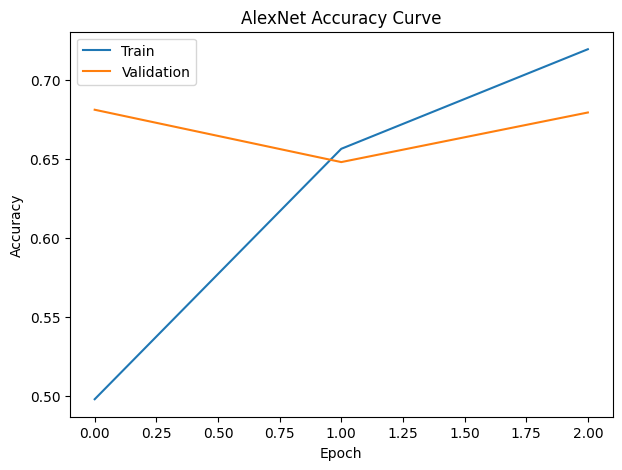

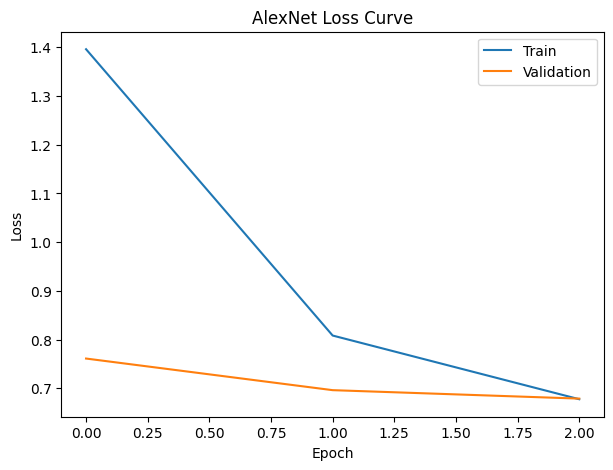

In [54]:
alexnet = build_alexnet()
alexnet.compile(optimizer=Adam(1e-4),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_alex = alexnet.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld),
    class_weight=new_weights
)
plot_history(history_alex, "AlexNet")


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.4254 - loss: 1.2493 - val_accuracy: 0.3937 - val_loss: 1.1781
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5768 - loss: 1.0517 - val_accuracy: 0.6307 - val_loss: 0.8796
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6328 - loss: 0.9234 - val_accuracy: 0.7387 - val_loss: 0.7336


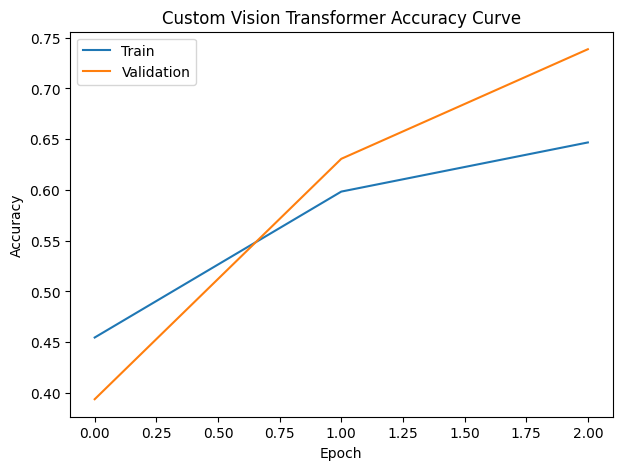

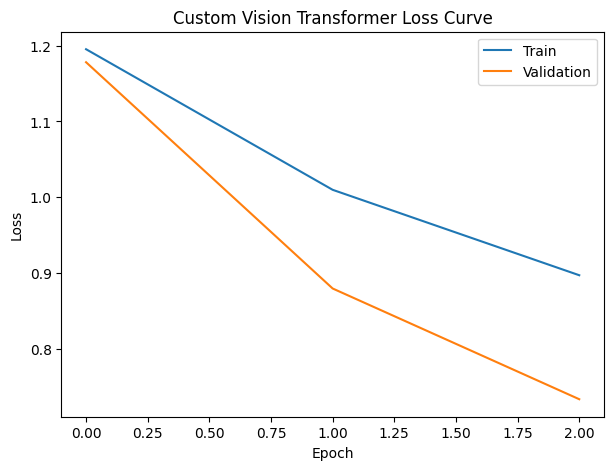

In [55]:
vit_small = build_vit_small()
vit_small.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vits = vit_small.fit(
    Xtrain_vgg, ytrain,
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, yVld)
)

plot_history(history_vits, "Custom Vision Transformer")


Epoch 1/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 32s 84ms/step - accuracy: 0.7384 - loss: 2.8586 - val_accuracy: 1.0000 - val_loss: 0.0584
Epoch 2/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.7138 - loss: 0.9036 - val_accuracy: 0.9983 - val_loss: 0.1837
Epoch 3/3
336/336 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - accuracy: 0.8140 - loss: 0.5737 - val_accuracy: 0.9948 - val_loss: 0.3014


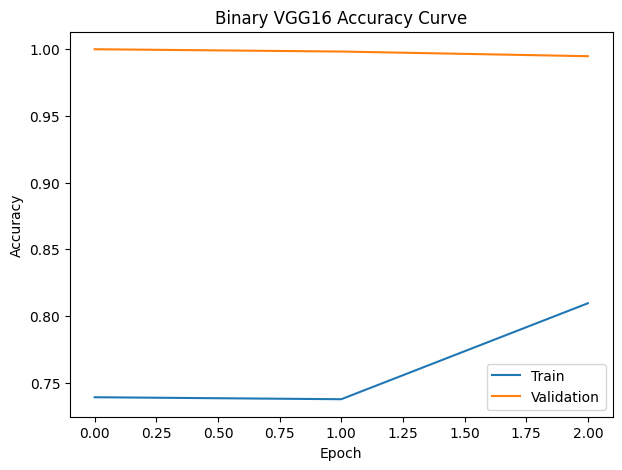

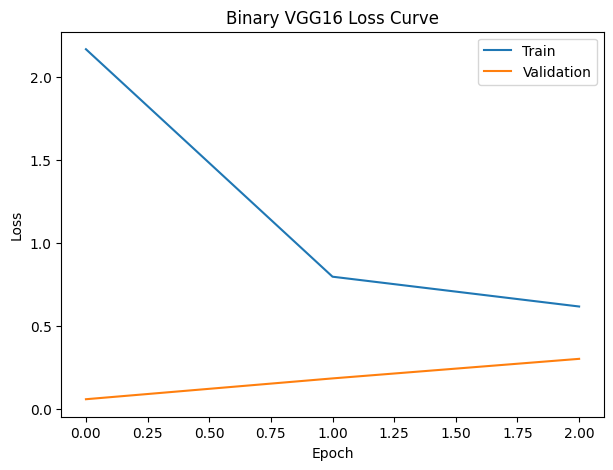

In [56]:

binary_vgg = build_binary_vgg16()
binary_vgg.compile(optimizer=Adam(1e-4),
                   loss="binary_crossentropy",
                   metrics=["accuracy"])

history_binary = binary_vgg.fit(
    Xtrain_vgg, y_binary[:len(Xtrain_vgg)],
    batch_size=8,
    epochs=3,
    validation_data=(XVld_vgg, y_binary[-len(XVld_vgg):])
)

plot_history(history_binary, "Binary VGG16")


In [57]:
def evaluate_model(model, model_name):
    ypred = model.predict(XVld_vgg)
    ypred = np.argmax(ypred, axis=1)

    print(f"\n===== {model_name} Classification Report =====\n")
    print(classification_report(yVld, ypred, target_names=categories))

    cm = confusion_matrix(yVld, ypred)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()


18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 618ms/step

===== MobileNetV2 Classification Report =====

                  precision    recall  f1-score   support

    glioma_tumor       0.85      0.83      0.84       179
meningioma_tumor       0.81      0.64      0.72       169
        no_tumor       0.76      0.96      0.85        70
 pituitary_tumor       0.86      0.97      0.91       156

        accuracy                           0.83       574
       macro avg       0.82      0.85      0.83       574
    weighted avg       0.83      0.83      0.82       574



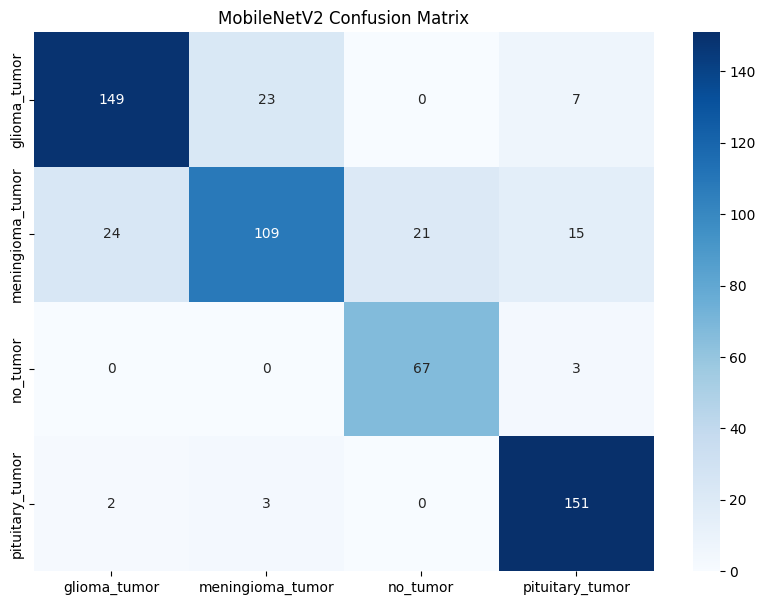

18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 705ms/step

===== InceptionV3 Classification Report =====

                  precision    recall  f1-score   support

    glioma_tumor       0.65      0.61      0.63       179
meningioma_tumor       0.55      0.52      0.54       169
        no_tumor       0.72      0.76      0.74        70
 pituitary_tumor       0.81      0.88      0.84       156

        accuracy                           0.68       574
       macro avg       0.68      0.69      0.69       574
    weighted avg       0.67      0.68      0.67       574



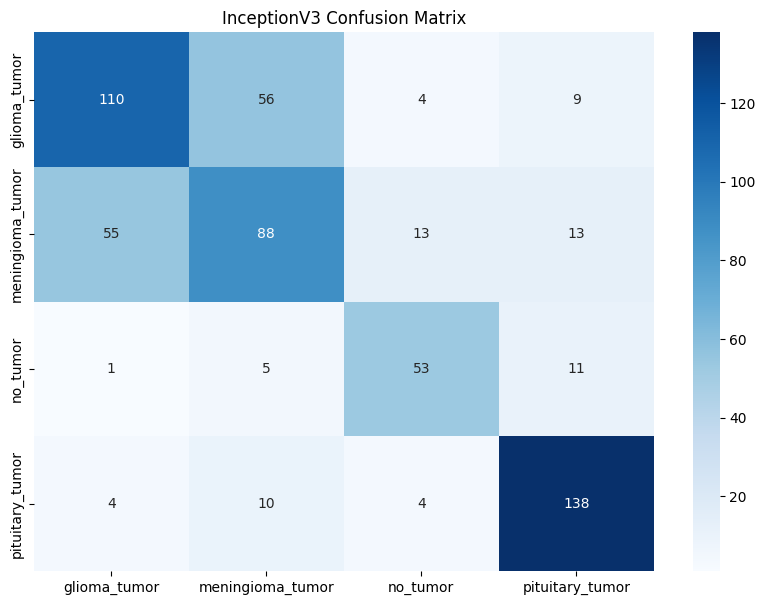

18/18 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step

===== Xception Classification Report =====

                  precision    recall  f1-score   support

    glioma_tumor       0.71      0.80      0.75       179
meningioma_tumor       0.70      0.56      0.62       169
        no_tumor       0.74      0.79      0.76        70
 pituitary_tumor       0.85      0.89      0.87       156

        accuracy                           0.75       574
       macro avg       0.75      0.76      0.75       574
    weighted avg       0.75      0.75      0.75       574



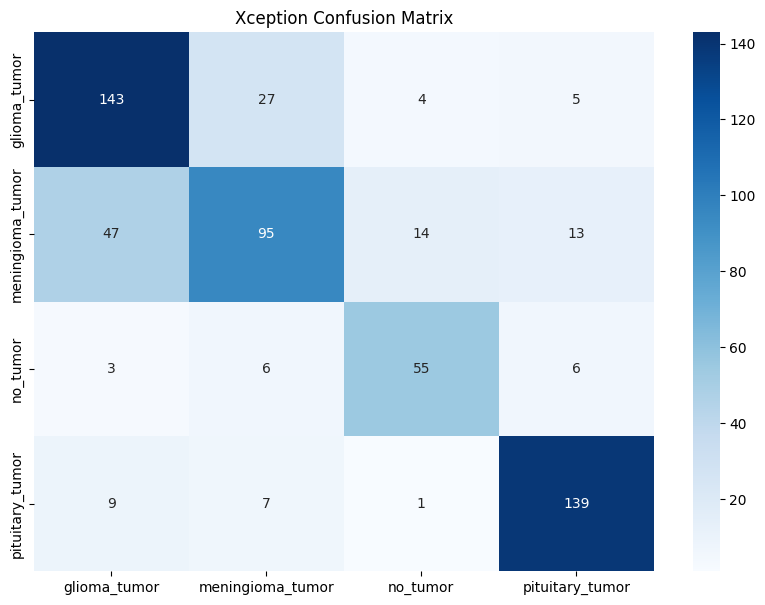

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step

===== MSCNN Classification Report =====

                  precision    recall  f1-score   support

    glioma_tumor       0.96      0.82      0.88       179
meningioma_tumor       0.76      0.86      0.81       169
        no_tumor       0.79      0.81      0.80        70
 pituitary_tumor       0.96      0.98      0.97       156

        accuracy                           0.87       574
       macro avg       0.87      0.87      0.87       574
    weighted avg       0.88      0.87      0.87       574



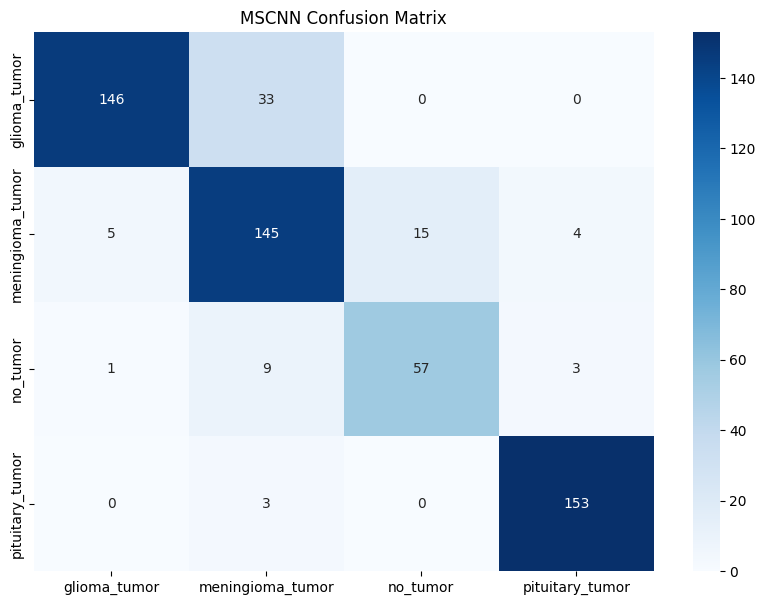

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step

===== AlexNet Classification Report =====

                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.30      0.45       179
meningioma_tumor       0.49      0.83      0.61       169
        no_tumor       0.73      0.83      0.78        70
 pituitary_tumor       0.93      0.89      0.91       156

        accuracy                           0.68       574
       macro avg       0.77      0.71      0.69       574
    weighted avg       0.77      0.68      0.66       574



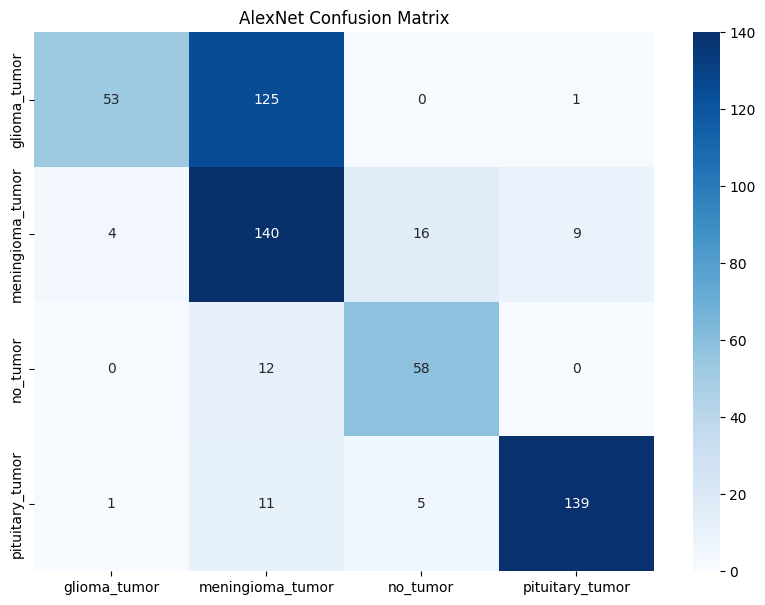

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step

===== Custom Vision Transformer Classification Report =====

                  precision    recall  f1-score   support

    glioma_tumor       0.70      0.87      0.77       179
meningioma_tumor       0.82      0.44      0.57       169
        no_tumor       0.69      0.70      0.70        70
 pituitary_tumor       0.77      0.92      0.84       156

        accuracy                           0.74       574
       macro avg       0.74      0.73      0.72       574
    weighted avg       0.75      0.74      0.72       574



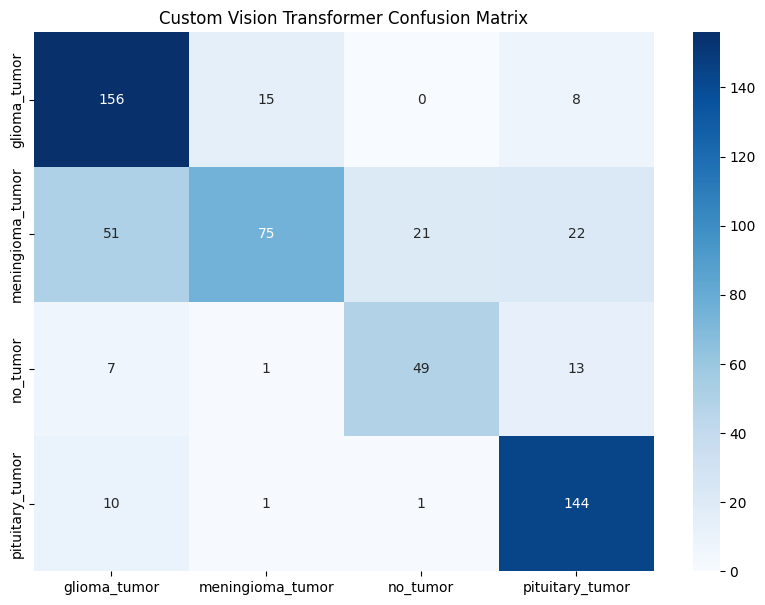

In [58]:
evaluate_model(mobilenet, "MobileNetV2")
evaluate_model(inception, "InceptionV3")
evaluate_model(xception, "Xception")
evaluate_model(mscnn, "MSCNN")
evaluate_model(alexnet, "AlexNet")
evaluate_model(vit_small, "Custom Vision Transformer")


18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step

===== BINARY VGG16 Classification Report =====

                  precision    recall  f1-score   support

    glioma_tumor       0.31      1.00      0.48       179
meningioma_tumor       0.00      0.00      0.00       169
        no_tumor       0.00      0.00      0.00        70
 pituitary_tumor       0.00      0.00      0.00       156

        accuracy                           0.31       574
       macro avg       0.08      0.25      0.12       574
    weighted avg       0.10      0.31      0.15       574



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


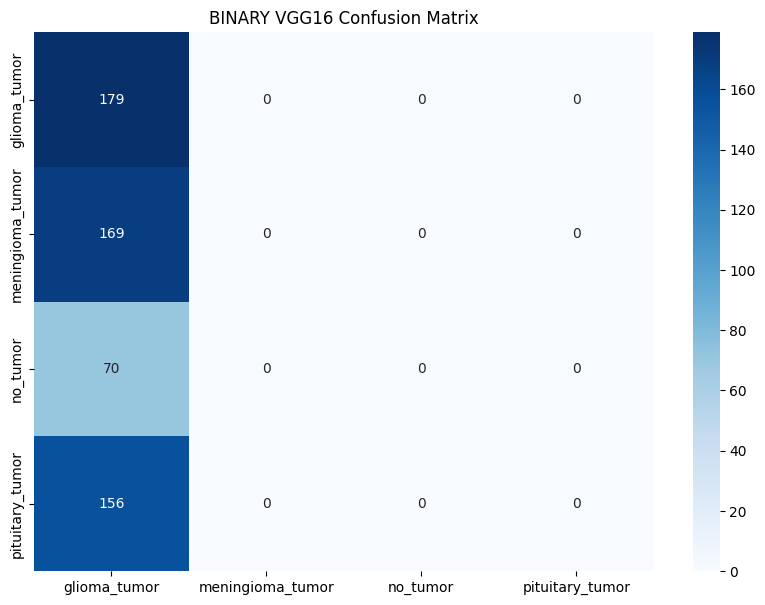

In [59]:
evaluate_model(binary_vgg, "BINARY VGG16")

In [60]:
def train_with_params(lr, batch):
    model = build_vgg16_imagenet()
    model.compile(optimizer=Adam(lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    h = model.fit(
        Xtrain_vgg, ytrain,
        batch_size=batch,
        epochs=2,
        validation_data=(XVld_vgg, yVld),
        verbose=0
    )
    return h.history['val_accuracy'][-1]

params = [(1e-4,8), (1e-4,16), (5e-5,8), (5e-5,16)]
results = []

for lr, batch in params:
    acc = train_with_params(lr, batch)
    results.append([lr, batch, acc])

df_tuning = pd.DataFrame(results, columns=["LR", "Batch", "Val Accuracy"])
print(df_tuning)


        LR  Batch  Val Accuracy
0  0.00010      8      0.770035
1  0.00010     16      0.775261
2  0.00005      8      0.777003
3  0.00005     16      0.796167


In [61]:
model_accuracies = {
    # "VGG16": history_vgg.history['val_accuracy'][-1],
    # "ResNet50": history_rn.history['val_accuracy'][-1],
    "EfficientNetB0": history_effnet.history['val_accuracy'][-1],
    "DenseNet121": history_dense.history['val_accuracy'][-1],
    "MobileNetV2": history_mbn.history['val_accuracy'][-1],
    "InceptionV3": history_inc.history['val_accuracy'][-1],
    "Xception": history_xc.history['val_accuracy'][-1],
    "MSCNN": history_mscnn.history['val_accuracy'][-1],
    "AlexNet": history_alex.history['val_accuracy'][-1],
    # "Custom Vision Transformer": history_vits.history['val_accuracy'][-1],
}


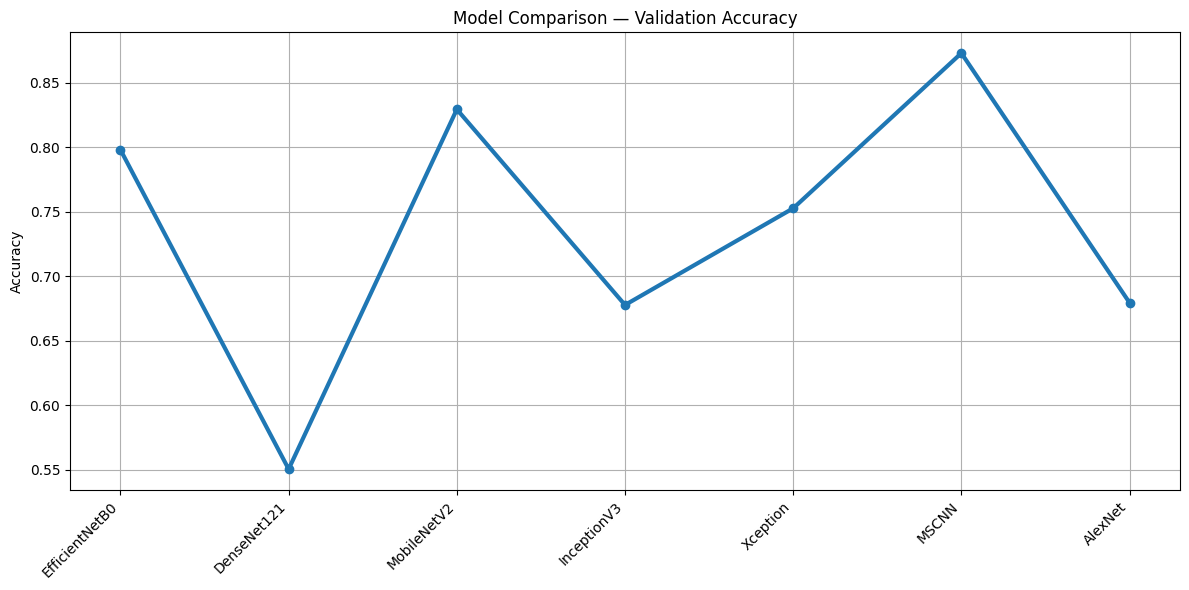

In [62]:
plt.figure(figsize=(12, 6))

names = list(model_accuracies.keys())
values = list(model_accuracies.values())

plt.plot(names, values, marker='o', linewidth=3)
plt.xticks(rotation=45, ha='right')
plt.title("Model Comparison — Validation Accuracy")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


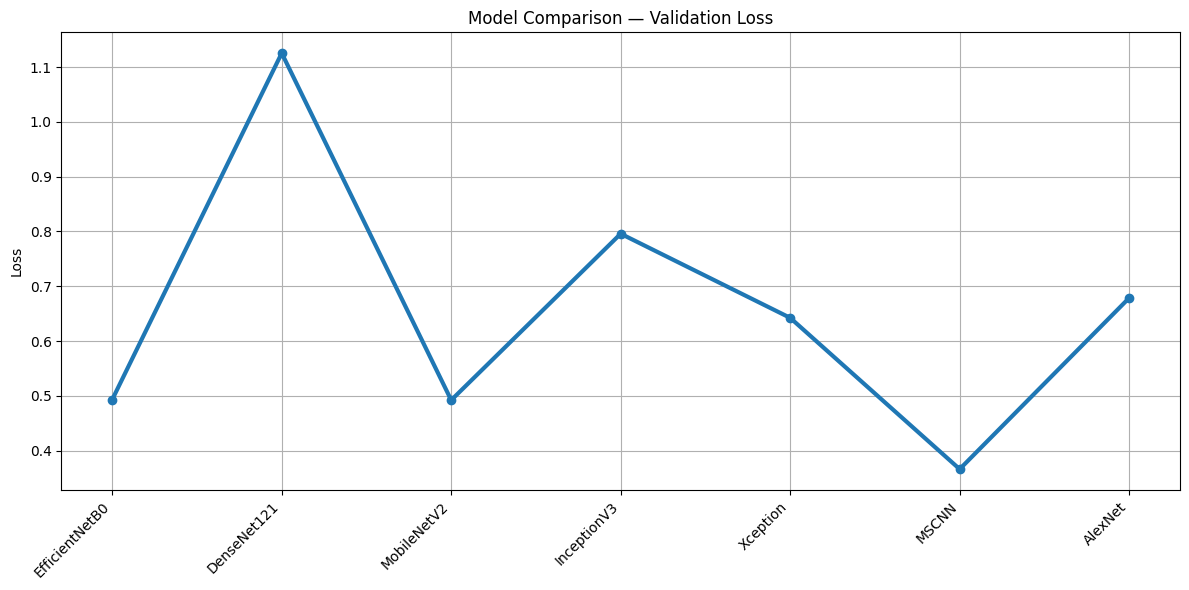

In [63]:
model_losses = {
    # "VGG16": history_vgg.history['val_loss'][-1],
    # "ResNet50": history_rn.history['val_loss'][-1],
    "EfficientNetB0": history_effnet.history['val_loss'][-1],
    "DenseNet121": history_dense.history['val_loss'][-1],
    "MobileNetV2": history_mbn.history['val_loss'][-1],
    "InceptionV3": history_inc.history['val_loss'][-1],
    "Xception": history_xc.history['val_loss'][-1],
    "MSCNN": history_mscnn.history['val_loss'][-1],
    "AlexNet": history_alex.history['val_loss'][-1],
    # "Custom Vision Transformer": history_vits.history['val_accuracy'][-1],
}

plt.figure(figsize=(12, 6))
plt.plot(list(model_losses.keys()), list(model_losses.values()), marker='o', linewidth=3)
plt.xticks(rotation=45, ha='right')
plt.title("Model Comparison — Validation Loss")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


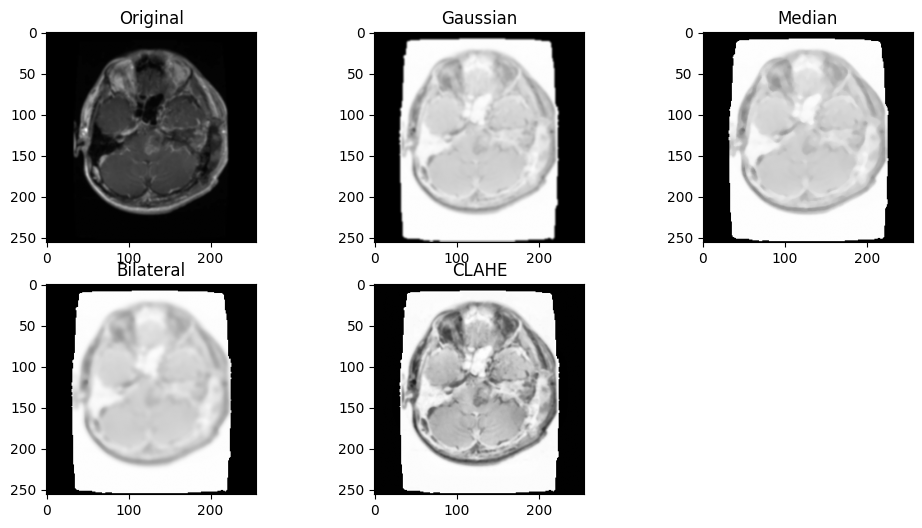

In [64]:
i = 100

orig = X[i].squeeze()
g, m, b = denoise_image(orig)
clahe_img = apply_clahe(orig)

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(orig, cmap='gray'); plt.title("Original")
plt.subplot(2,3,2); plt.imshow(g, cmap='gray'); plt.title("Gaussian")
plt.subplot(2,3,3); plt.imshow(m, cmap='gray'); plt.title("Median")
plt.subplot(2,3,4); plt.imshow(b, cmap='gray'); plt.title("Bilateral")
plt.subplot(2,3,5); plt.imshow(clahe_img, cmap='gray'); plt.title("CLAHE")
plt.show()


In [65]:
def preprocess_gui_image(img):
    img = img.resize((256, 256))
    img_arr = np.array(img) / 255.0


    if img_arr.ndim == 2 or img_arr.shape[-1] == 1:
     img_arr = np.stack([img_arr]*3, axis=-1)


    return img_arr.astype('float32')

In [66]:
dummy = np.zeros((1,256,256,3))

vgg16_tl.predict(dummy)
resnet50_tl.predict(dummy)
effnet.predict(dummy)
mobilenet.predict(dummy)
inception.predict(dummy)
xception.predict(dummy)
alexnet.predict(dummy)
vit_small.predict(dummy)
mscnn.predict(dummy)
binary_vgg.predict(dummy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step


array([[0.60466135]], dtype=float32)

In [67]:
import tensorflow as tf
import numpy as np
import cv2

def generate_gradcam(model, img_array):


    conv_layer = None
    for layer in reversed(model.layers):
        if hasattr(layer, "output") and len(layer.output.shape) == 4:
            conv_layer = layer.name
            break

    if conv_layer is None:
        print(" No conv layer found — returning blank heatmap")
        return np.zeros((256,256))

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(conv_layer).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]

    heatmap = tf.reduce_sum(tf.multiply(pooled, conv_out), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-10)
    heatmap = cv2.resize(heatmap, (256,256))

    return heatmap


In [68]:
print("Warming up models...")
vgg16_tl.predict(np.zeros((1,256,256,3)))
resnet50_tl.predict(np.zeros((1,256,256,3)))
effnet.predict(np.zeros((1,256,256,3)))
densenet.predict(np.zeros((1,256,256,3)))
mobilenet.predict(np.zeros((1,256,256,3)))
inception.predict(np.zeros((1,256,256,3)))
xception.predict(np.zeros((1,256,256,3)))
alexnet.predict(np.zeros((1,256,256,3)))
mscnn.predict(np.zeros((1,256,256,3)))
vit_small.predict(np.zeros((1,256,256,3)))
binary_vgg.predict(np.zeros((1,256,256,3)))
print("All models warmed up.")


Warming up models...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
All models warmed up.


In [69]:
models_dict = {
    "MSCNN": mscnn,
    "EfficientNetB0": effnet,
    "DenseNet121": densenet,
    "MobileNetV2": mobilenet,
    "InceptionV3": inception,
    "Xception": xception,
    "AlexNet": alexnet,
    "VGG16": vgg16_tl,
    "ResNet50": resnet50_tl,
    "Vision Transformer": vit_small,
    "Binary VGG": binary_vgg
}

categories = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]


In [70]:
def gui_predict(img, model_name):
    model = models_dict[model_name]


    img_arr = preprocess_gui_image(img)
    img_arr = np.expand_dims(img_arr, axis=0)


    if model_name == "Binary VGG":
        pred = model.predict(img_arr)[0][0]
        label = "Tumor" if pred > 0.5 else "No Tumor"
        heatmap = generate_gradcam(model, img_arr)
        return label, heatmap


    preds = model.predict(img_arr)[0]
    idx = np.argmax(preds)
    label = categories[idx]

    heatmap = generate_gradcam(model, img_arr)
    return label, heatmap


In [71]:
dummy = np.zeros((1,256,256,3))
for m in models_dict.values():
    m.predict(dummy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [ ]:
gui = gr.Interface(
    fn=gui_predict,
    inputs=[
        gr.Image(type="pil", label="Upload MRI Image"),
        gr.Dropdown(list(models_dict.keys()), label="Select Model")
    ],
    outputs=[
        gr.Text(label="Prediction"),
        gr.Image(label="Grad-CAM Heatmap")
    ],
    title="Brain Tumor Classification GUI",
    description="Upload an MRI image, select a model, and view Grad-CAM heatmaps."
)

gui.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0853d286d2822e7a91.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
